In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Titanic Survival Prediction

This project aims to analyze Titanic passenger data, identify factors affecting survival, and build a classification model to predict whether a passenger survived.

## 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Dataset

In [21]:
train_df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Overview

In [22]:
train_df.shape

(891, 12)

In [23]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [24]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [25]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Data Cleaning

In [26]:
#First check the number of missing values
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
#Delete columns with high missing values ​​and irrelevant columns.
train_df = train_df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])
test_df = test_df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

In [28]:
#Imputing Missing Values
#1. Age: Impute with the median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

In [29]:
#2. Embarked (fill in with the mode)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

In [30]:
#Fare, please check it as well.
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

In [31]:
#Encoding categorical variables
#male → 0，female → 1
#Embarked mapping
#S → 0，C → 1，Q → 2
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [32]:
#check if there are any missing values.
train_df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [33]:
test_df.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [34]:
train_df.isnull().sum().sum()

np.int64(0)

In [35]:
test_df.isnull().sum().sum()

np.int64(0)

Missing values were handled by removing the `Cabin` column due to excessive missing data, filling `Age` and `Fare` with the median, and filling `Embarked` with the mode. Categorical variables such as `Sex` and `Embarked` were then encoded into numerical values for model training.

## 5. Exploratory Data Analysis

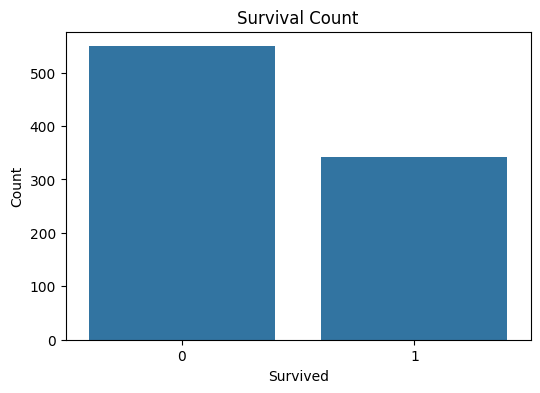

In [36]:
#Distribution of Survivors
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

The survival count plot shows that more passengers did not survive than survived. This indicates that the Titanic dataset is slightly imbalanced, with non-survivors making up the larger group.

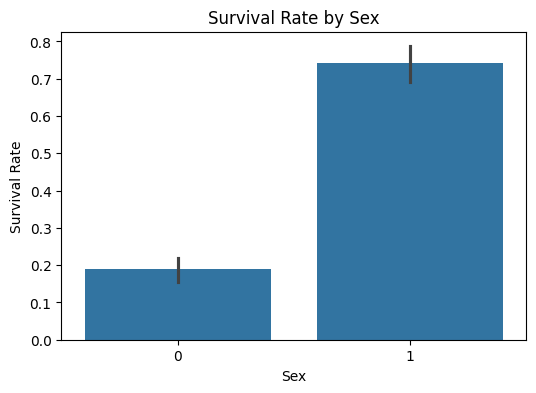

In [37]:
#Gender and Survival Rate
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

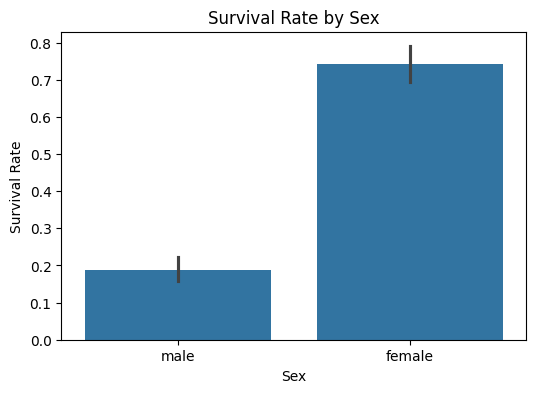

In [39]:
train_df['Sex_label'] = train_df['Sex'].map({0: 'male', 1: 'female'})

plt.figure(figsize=(6,4))
sns.barplot(x='Sex_label', y='Survived', data=train_df)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

The survival rate by sex shows a clear difference between male and female passengers. Female passengers had a much higher survival rate than male passengers, suggesting that sex was one of the most important factors affecting survival on the Titanic.

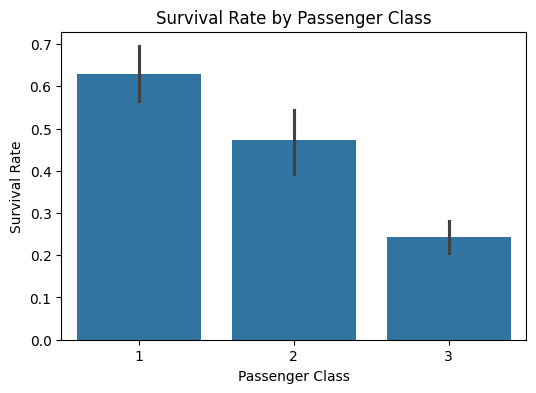

In [40]:
#Cabin class and survival rate
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

The survival rate by passenger class suggests that passengers in higher classes were more likely to survive. First-class passengers had the highest survival rate, while third-class passengers had the lowest, indicating that passenger class was strongly associated with survival.

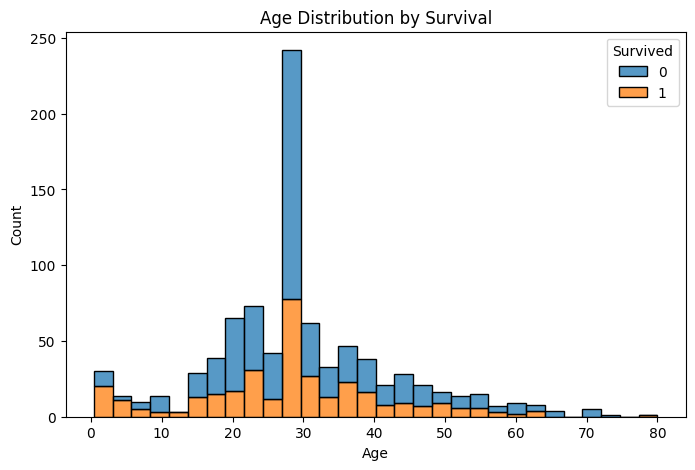

In [41]:
#Age distribution and survival rate
plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The age distribution plot suggests that survival varied across age groups. Younger passengers, especially children, appear to have relatively better survival outcomes, while adult passengers make up the majority of both survivors and non-survivors.

### EDA Summary

The exploratory analysis suggests that sex and passenger class were the strongest factors associated with survival on the Titanic. Female passengers and first-class passengers had clearly higher survival rates. Age also appears to have some influence, with children showing relatively better survival outcomes. These findings provide a useful basis for selecting features for the classification model.

## 6. Feature Selection
The selected features include passenger class, sex, age, family-related variables, fare, and embarkation port, as these factors are likely to influence survival outcomes.

In [42]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = train_df[features]
y = train_df['Survived']
X_test_final = test_df[features]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


## 7. Model Building
A Logistic Regression model was used as the baseline classification model to predict passenger survival.

In [43]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 8. Model Evaluation

In [44]:
y_pred = model.predict(X_valid)

accuracy = accuracy_score(y_valid, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


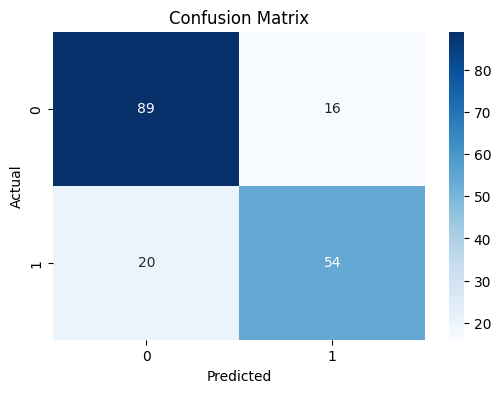

In [46]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The model performs slightly better in predicting non-surviving passengers (0) and slightly weaker in identifying surviving passengers (1). However, its overall performance is relatively balanced, without a significant bias towards any one category.

In [47]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



The Logistic Regression model achieved an accuracy of **0.799**, which means it correctly classified about 79.9% of the validation samples. 

The confusion matrix shows that the model performed slightly better in identifying non-survivors than survivors. According to the classification report, the model achieved a precision of **0.82** and recall of **0.85** for non-survivors, while for survivors it achieved a precision of **0.77** and recall of **0.73**.

Overall, the model provides a solid baseline for Titanic survival prediction. Although the performance is reasonably good, there is still room for improvement through feature engineering or more advanced classification models.

## 9. Test Prediction and Submission

In [48]:
test_predictions = model.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': pd.read_csv('/kaggle/input/competitions/titanic/test.csv')['PassengerId'],
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [49]:
submission.to_csv('submission.csv', index=False)

## 10. Conclusion

This project analyzed Titanic passenger data and built a Logistic Regression model to predict survival outcomes. After cleaning the data and handling missing values, exploratory data analysis showed that sex, passenger class, and age were important factors related to survival.

The results indicated that female passengers and first-class passengers had higher survival rates, while non-survivors formed the larger group overall. The Logistic Regression model achieved an accuracy of about 79.9%, making it a reasonable baseline classification model for this task.

In the future, model performance could be improved by applying additional feature engineering, testing other algorithms such as Random Forest, and tuning hyperparameters.